# 프로젝트 1 : 손수 설계하는 선형회귀, 당뇨병 수치를 맞춰보자!

데이터는 sklearn.datasets에 있는 데이터 중 하나인 당뇨병 데이터를 사용하겠습니다.
데이터에 관한 정보를 다음 글에서 살펴보세요. 데이터에 대한 이해는 언제나 첫 번째로 해야하는 필수 과정입니다!

!(당뇨병 데이터셋 예시로 보는 다중 선형 회귀)[https://modulabs.co.kr/blog/diabetes-dataset-multi-linear-regression?_gl=1*18xiuxy*_gcl_aw*R0NMLjE3NzQyNTE2MDkuQ2p3S0NBand5WVBPQmhCeEVpd0FncFQ4UHlrbEJUUExEUjUzcDNHM2RaT0NaZ1ZPV1N6OTd0NmoyVjVmWk9lT04yYXdCTDNTbG9oX0NSb0NjczRRQXZEX0J3RQ..*_gcl_au*MTExOTQwMzQwMC4xNzcyNjY4MDc1LjEzODE5NzAyMDQuMTc3NDYwNzA2NS4xNzc0NjA3MTU3*_ga*NDA5MDExMDI0LjE3NzI2NjgwNzU.*_ga_5YVT7K6RHZ*czE3NzUxOTI3NDAkbzc5JGcxJHQxNzc1MTk1Nzk4JGoxNSRsMCRoMA..]

### (1) 데이터 가져오기

In [1]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

# scikit-learn 스킷런 라이브러리에서 당뇨병 데이터셋을 불러와 data 변수에 담습니다.
# df_X 에는 데이터 전부를 넣고, df_y에는 타겟데이터 (우리가 예측할 데이터) 를 넣습니다
# 확인해보면
df_X, df_y

(array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59.

In [2]:
#df_X는 2차원배열, df_y는 1차원배열로 맞는것 같습니다만 먼저 열이름을 확인해보겠습니다.
print(data.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [3]:
print(df_X.shape)
print(df_y.shape)

(442, 10)
(442,)


In [17]:
# 위 링크글을 보니 나이, 성별, 체지방지수, 혈압, s1~6 총 10개의 카테고리가 있고
# 특성값은 -0.2 ~ 0.2 분포하도록 되어있습니다. 데이터는 잘 로드 된것 같습니다.
# 나이 성별 bmi지수 같은것도 다 ~0.2~0.2 인것을 보면 Normalization이 모든 열에대해 진행이 되있는걸
# 알수 있습니다.

In [58]:
import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [7]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [9]:
y = np.array(df_y)

print(type(y), y.dtype)
# numpy 라이브러리를 사용하기위해 df_X값 -> X , df_y -> y  | numpy array로 변환해줍니다.

<class 'numpy.ndarray'> float64


In [10]:
# 스킷런에있는 train_test_split 함수로 테스트 데이터를 분리하겠습니다.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


# 분리 데이터 개수 시각화
 442개의 데이터중 20%인 89개가 테스트 데이터로 분리되고 나머지 353개가 입력데이터로 남았습니다

In [59]:
# 모델 준비하기
# 총 10개의 데이터가 있기때문에 W에는 10개의 난수 b에는 1개의 난수를  Numpy함수를 사용해 준비합니다
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [14]:
# 모델함수를 정의합니다, 데이터 갯수만큼 반복문을 돌며 예측치 계산하여 리턴합니다
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [19]:
# 손실함수를 정의합니다
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [18]:
# 위에서 정의한 모델함수 손실함수를 사용해서 loss를 판단하는 함수를 정의합니다.
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [22]:
# Gradient 함수를 정의합니다. 수치미분보다 빠르고 정확한 해석미분 방식을 적용합니다.
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [42]:
#학습율은 0.001로 먼저 시도해보겠습니다
LEARNING_RATE = 0.1

# 모델 학습하기
정의한 함수들로 학습을 합니다
첫시도에서 학습율 0.001로 1000회 반복했는데  Loss가 6418이고 변화율이 꽤남아있습니다 횟수를 5배로 늘립니다.
횟수를 5배 10배로 늘려도 Loss 3천 이하를 달성하는데 한참 못미칩니다.
학습율을 0.01로 해도 1만회 반복시 3443으로 3000을 초과하네요.
학습율을 0.1로 설정하고 반복 1만회를 유지해봅니다.

MSE 손실함수값: 2897 < 3000 달성

In [60]:
%%time
# %%timeit -n 1 -r 1  어차피 1번 반복하니까 아래 셀에서 losses 변수접근을위해 time으로 변경
global W, b

losses = []

for i in range(1, 10001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 5375.2787
Iteration 200 : Loss 4873.8885
Iteration 300 : Loss 4501.0507
Iteration 400 : Loss 4220.1183
Iteration 500 : Loss 4005.3098
Iteration 600 : Loss 3838.4436
Iteration 700 : Loss 3706.6577
Iteration 800 : Loss 3600.8187
Iteration 900 : Loss 3514.4096
Iteration 1000 : Loss 3442.7533
Iteration 1100 : Loss 3382.4686
Iteration 1200 : Loss 3331.0909
Iteration 1300 : Loss 3286.8052
Iteration 1400 : Loss 3248.2590
Iteration 1500 : Loss 3214.4318
Iteration 1600 : Loss 3184.5419
Iteration 1700 : Loss 3157.9812
Iteration 1800 : Loss 3134.2693
Iteration 1900 : Loss 3113.0203
Iteration 2000 : Loss 3093.9192
Iteration 2100 : Loss 3076.7052
Iteration 2200 : Loss 3061.1593
Iteration 2300 : Loss 3047.0952
Iteration 2400 : Loss 3034.3530
Iteration 2500 : Loss 3022.7939
Iteration 2600 : Loss 3012.2967
Iteration 2700 : Loss 3002.7545
Iteration 2800 : Loss 2994.0730
Iteration 2900 : Loss 2986.1684
Iteration 3000 : Loss 2978.9658
Iteration 3100 : Loss 2972.3984
Iteration 3200 : 

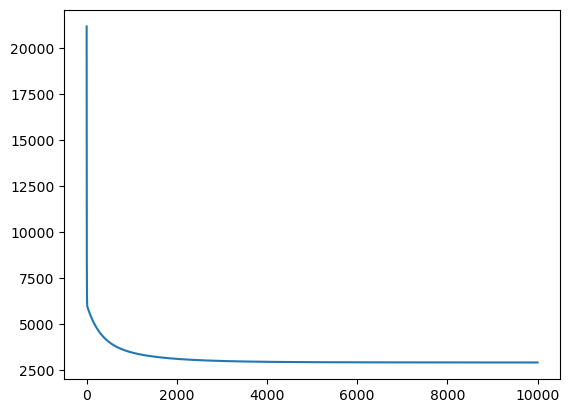

In [61]:
### 7500회 반복 할때쯤 2900아래로 진입하고 10000회에서 2898 변화율이 거의 없습니다. 이정도면 된것 같네요
#matplot 라이브러리로 loss값을 그래프로 시각화 해보겠습니다.
import matplotlib.pyplot as plt

plt.plot(losses)
plt.show()

In [ ]:
# 그래프를 보니 5천회만 해도 충분했을것 같지만 여전히 10000회 결과가 더 좋으니 그대로 사용하겠습니다.

In [45]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2880.157326075787)

# 정답데이터와 예측한 데이터를 시각화 해보겠습니다.

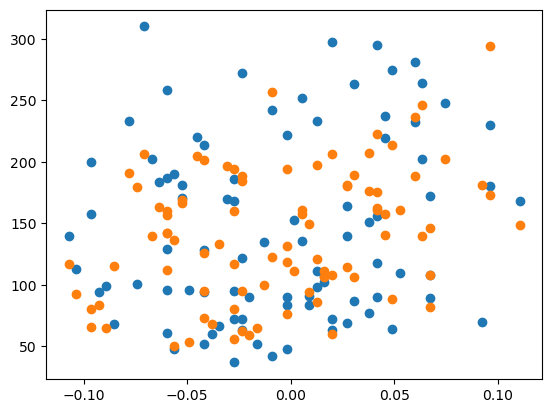

In [62]:


plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

In [64]:
# 분포도가 비슷한걸 확인할수 있습니다. 예측한 결과가 좀더 안쪽으로 군집해있는걸 볼수 있습니다.

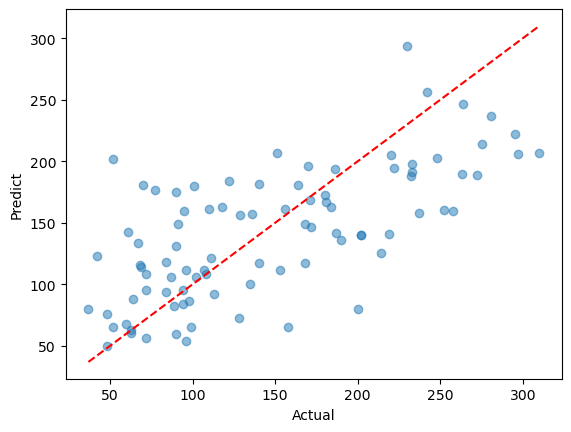

In [67]:
# 추가로 Test : Predict 그래프를 그려보면 다른각도에서 결과를 분석해 볼수 있습니다.

# 점 하나는 환자 한명을 의미하는데, x축에는 정답을, y축예는 예상치를 출력합니다. 
# 따라서 실제 당뇨수치가 예측치와 가까울수록 빨간선과 가깝게 위치하게됩니다.
# 결과를 보면 크게 붙어있지 않지만 어느정도 추세는 맞춘걸 알수 있습니다.
plt.scatter(y_test, prediction, alpha=0.5) 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # 정답선
plt.xlabel('Actual')
plt.ylabel('Predict')
plt.show()

# 프로젝트 2: 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?

In [ ]:
# 캐글 경진대회에서 제공하는 데이터셋에 시간 온도 습도 계절등의 정보가 담겨있는데,
# 이것으로 자전거 대여량을 예측하는 모델을 만들어 봅니다.

In [68]:
import pandas as pd

train = pd.read_csv("~/work/workplace/Data_Analysis/DA01/data/train.csv") 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [70]:
# datetime 컬럼을 datetime 자료형으로 변환하고 연, 월, 일, 시, 분, 초까지 6가지 컬럼 생성하기
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

#train['datetime']에 있는 연 월 시 일 분 초 데이터를 별도로 만든 열에 분리해줍니다.

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

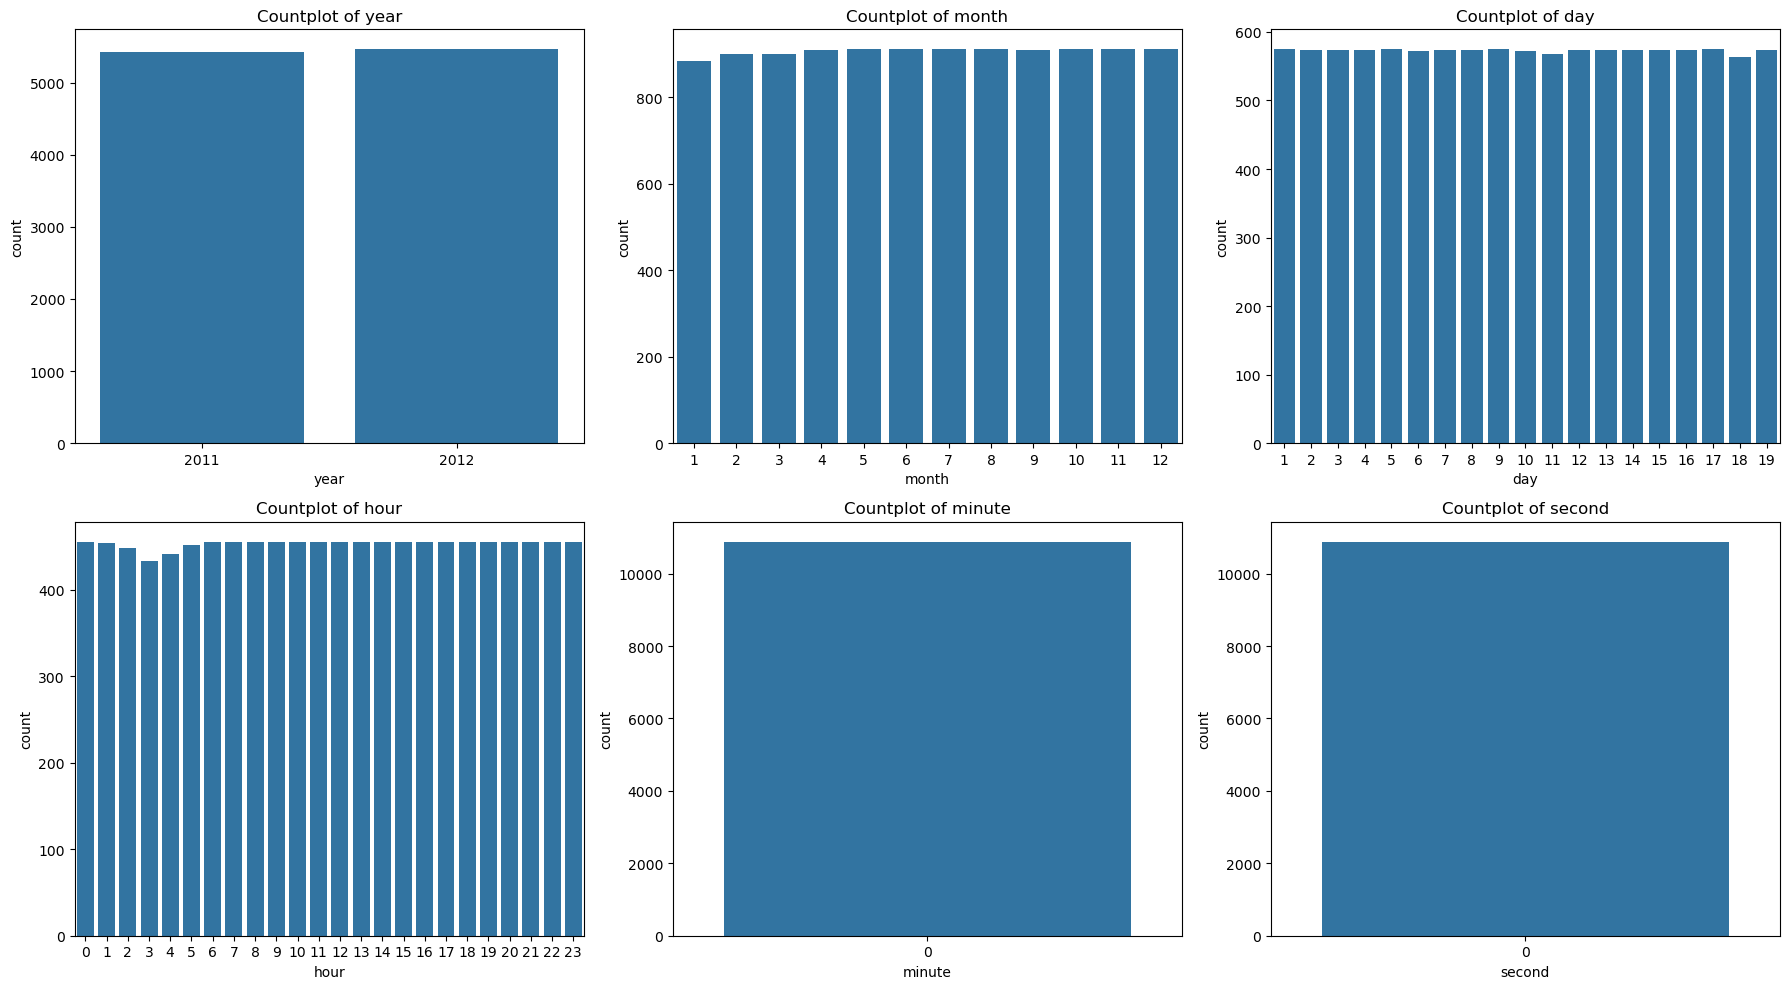

In [71]:
# 아래 int32타입의 6개의 열이 추가로 생긴걸 볼수있습니다.
# year, month, day, hour, minute, second 데이터 개수 시각화하기
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()


In [75]:
# minute와 second에는 0값밖에 없는걸보니 datetime 값이 시간까지만 저장된것 같습니다.
# X, y 컬럼 선택 및 train/test 데이터 분리, 시간데이터는 hour까지만 포함하고 분,초는 제외
# 그외에 온도 습도 풍속도 고려사항으로 추가.
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 20%를 테스트 데이터로 분류


In [78]:
#10886개의 데이터 가 8708개 / 2178개의 학습 / 테스트 데이터로 분류됨
print(X, y)
print(X_train.shape, X_test.shape)

       year  month  day  hour   temp  humidity  windspeed
0      2011      1    1     0   9.84        81     0.0000
1      2011      1    1     1   9.02        80     0.0000
2      2011      1    1     2   9.02        80     0.0000
3      2011      1    1     3   9.84        75     0.0000
4      2011      1    1     4   9.84        75     0.0000
...     ...    ...  ...   ...    ...       ...        ...
10881  2012     12   19    19  15.58        50    26.0027
10882  2012     12   19    20  14.76        57    15.0013
10883  2012     12   19    21  13.94        61    15.0013
10884  2012     12   19    22  13.94        61     6.0032
10885  2012     12   19    23  13.12        66     8.9981

[10886 rows x 7 columns] 0         16
1         40
2         32
3         13
4          1
        ... 
10881    336
10882    241
10883    168
10884    129
10885     88
Name: count, Length: 10886, dtype: int64
(8708, 7) (2178, 7)


In [137]:
# 스킷런 라이브러리를 사용해서 선영회귀 모델로 학습
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [138]:
# 모델을 사용해서 예측치를 뽑고
# 스킷런 라이브러리로 평균 제곱 오차 측정하고
# 단위를 되돌리기 위해  rmse로 변환
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 21586.191552303328
RMSE: 146.92239976362805


In [104]:
# 그리고 학습률 을 바꿀수있나 알아보았는데 사이킷런은 경사하강법을 쓰지않고 별도의 알고리즘을 사용한다고합니다.
# 대신 SGDRegressor를 사용할경우 경사 하강법을 쓸수 있다고 하네요.
# SGDRegressor을 사용하면 더 오차를 줄일수 있는지 알아봅니다.

from sklearn.linear_model import SGDRegressor
# from sklearn.metrics import mean_squared_error
# import numpy as np

# 1. 모델 객체 생성 (학습률 eta0=0.01 설정)
# learning_rate='constant'는 학습 내내 보폭을 일정하게 유지하라는 뜻입니다.
# invscaling = 학습하면서 보폭을 점점 줄이라는 뜻입니다.
model_sgd = SGDRegressor(max_iter=1000, eta0=0.000001, learning_rate='invscaling', random_state=42)

# 2. 모델 학습
model_sgd.fit(X_train, y_train)

# 3. 예측
y_pred = model_sgd.predict(X_test)

# 4. 성능 평가 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 22161.63276279501
RMSE: 148.86783656248588


In [105]:
#SGDRegressor을 사용해서 학습율을 조정해보았지만 141보다 더 좋은 수치는 찾기 어려웠습니다.

In [106]:
X_train, y_train

(      year  month  day  hour   temp  humidity  windspeed
 2815  2011      7    6     5  27.88        83     6.0032
 8695  2012      8    4    16  36.90        39    19.9995
 8406  2012      7   11    15  32.80        41    16.9979
 1543  2011      4   10     4  14.76        93     7.0015
 4952  2011     11   19    10  13.12        45    16.9979
 ...    ...    ...  ...   ...    ...       ...        ...
 5734  2012      1   14     2   6.56        47    11.0014
 5191  2011     12   10     9  11.48        61    19.0012
 5390  2011     12   18    16  11.48        48    16.9979
 860   2011      2   19     7  15.58        17    35.0008
 7270  2012      5    2     7  22.14        88    12.9980
 
 [8708 rows x 7 columns],
 2815     35
 8695    450
 8406    276
 1543      5
 4952    200
        ... 
 5734     38
 5191    149
 5390    234
 860      22
 7270    358
 Name: count, Length: 8708, dtype: int64)

# 모델의 성능을 높이기 위해 데이터 전처리

학습율을 조정하다보니 느꼈는데 학습율값은 데이터 크기에 민감하다고 배웠는데,
우리 데이터를 다시 살펴보니 데이터 크기가 중구난방입니다 Normalization이 필요하다고 생각이 듭니다.
또한, year값이 2011,2012 밖에 없습니다. 이후 예측할 데이터가 2011이나 2012라면 도움이 될지도 모르겠으나, 

1. 2020이나 2100처럼 크게 다른 데이터가 들어오면 오히려 데이터가 튀어서 오히려 방해요소가 될수도 있다는 생각이 들어서
2. year값은 제외 하도록 합니다. 먼저 year을 제외하고 나머지 데이터를 normalization 하겠습니다.
3. day값도 이게 월화수목금토일 을 구분하는거면 도움이 될수있을지 모르겠지만, 단순히  1일~31일을 구분해서는
   모델이 판단하는데 아무 도움이 안될것 같아서 제외하겠습니다.
4. month는 계절에 영향이 크고, hour도 새벽에 자전거타는사람은 거의없으니 중요한 요소같아요 그리고 주제 자체가
   오후 3시에 자전거 타는사람을 찾는거니 필수로 갖고있어야 겠죠.
5. 마지막으로 day대신 월화수..토일 요일을 넣어주면 도움이 될거같아요 주말에는 자전거 타는사람이 더 많으니까요

In [112]:
# holiday 컬럼 확인 (0: 평일/주말, 1: 공휴일)
print("--- Holiday Count ---")
print(train['holiday'].value_counts())

# workingday 컬럼 확인 (0: 휴일, 1: 평일)
print("\n--- Workingday Count ---")
print(train['workingday'].value_counts())

# weather 컬럼 확인 (1: 맑음 ~ 4: 아주 안 좋음)
print("\n--- Weather Count ---")
print(train['weather'].value_counts())

--- Holiday Count ---
holiday
0    10575
1      311
Name: count, dtype: int64

--- Workingday Count ---
workingday
1    7412
0    3474
Name: count, dtype: int64

--- Weather Count ---
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


In [113]:
# 공휴일, 주말/평일, 날씨 정보가 기본 테이블에 있는걸 확인해서 이들도 이용해보도록 하겠습니다

In [117]:
features = ['month', 'hour', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

# 1. 먼저 판다스를 dummies를 사용해서 원-핫 범주 카테고리 3개에 인코딩 적용
X_encoded = pd.get_dummies(X, columns=['holiday', 'workingday', 'weather'])
X_encoded


,month,hour,temp,humidity,windspeed,holiday_0,holiday_1,workingday_0,workingday_1,weather_1,weather_2,weather_3,weather_4
0,1,0,9.84,81,0.0000,True,False,True,False,True,False,False,False
1,1,1,9.02,80,0.0000,True,False,True,False,True,False,False,False
2,1,2,9.02,80,0.0000,True,False,True,False,True,False,False,False
3,1,3,9.84,75,0.0000,True,False,True,False,True,False,False,False
4,1,4,9.84,75,0.0000,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,12,19,15.58,50,26.0027,True,False,False,True,True,False,False,False
10882,12,20,14.76,57,15.0013,True,False,False,True,True,False,False,False
10883,12,21,13.94,61,15.0013,True,False,False,True,True,False,False,False
10884,12,22,13.94,61,6.0032,True,False,False,True,True,False,False,False


In [122]:
# 2. 표준화 하기전에 데이터 분할부터 해주겠습니다
# 정규화대신 표준화를 선택한 이유는, 값 차이가 큰 year값은 제거했지만 여전히 작은값은 0~4 이고 큰값은 80이 넘습니다
# 데이터 단위차이가 크므로 표준화가 적합해보입니다.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [123]:
# 3. Standardization 표준화 
from sklearn.preprocessing import OneHotEncoder, StandardScaler

scaler = StandardScaler()

# 학습데이터 변환 - 학습후 변환하는 fit_transfrom 함수사용
X_train_scaled = scaler.fit_transform(X_train)
#예측용 테스트데이터 변환
X_test_scaled = scaler.transform(X_test)

print("정규화 완료된 데이터 샘플:\n", X_train_scaled[0])

정규화 완료된 데이터 샘플:
 [ 0.13822447 -0.94596221  0.97726179  1.09855333 -0.82835619  0.17333479
 -0.17333479 -0.68444534  0.68444534  0.71357231 -0.58990475 -0.29312273
 -0.01071681]


In [124]:
#이전에 임포트한 선영회귀모델을 다시 사용합니다.
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [125]:
# 다시 오차값을 측정해봅니다 이전에 선형회귀를 사용했을때 값 RMSE=19961, MSE=141
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 21586.191552303328
RMSE: 146.92239976362805


In [126]:
# 이런! 오히려 값이 안좋아졌군요.

# 다시 위에서 시도해봤던 경사 하강법을 사용해보겠습니다.
model_sgd = SGDRegressor(max_iter=1000, eta0=0.000001, learning_rate='invscaling', random_state=42)

# 2. 모델 학습
model_sgd.fit(X_train, y_train)

# 3. 예측
y_pred = model_sgd.predict(X_test)

# 4. 성능 평가 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 21745.691687651644
RMSE: 147.46420476729816


In [127]:
# 학습율 값을 수정 1
model_sgd = SGDRegressor(max_iter=1000, eta0=0.00001, learning_rate='invscaling', random_state=42)

# 2. 모델 학습
model_sgd.fit(X_train, y_train)

# 3. 예측
y_pred = model_sgd.predict(X_test)

# 4. 성능 평가 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 21769.046315535074
RMSE: 147.5433709643882


In [136]:
# 학습율 값을 수정 2
model_sgd = SGDRegressor(max_iter=1000, eta0=0.0001, learning_rate='invscaling', random_state=42)

# 2. 모델 학습
model_sgd.fit(X_train, y_train)

# 3. 예측
y_pred_sgd = model_sgd.predict(X_test)

# 4. 성능 평가 
mse_sgd = mean_squared_error(y_test, y_pred)
rmse_sgd = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 21745.691687651644
RMSE: 147.46420476729816


In [141]:
# 학습율 값을 수정 3
model_sgd = SGDRegressor(max_iter=10000, eta0=0.000001, learning_rate='invscaling', random_state=42)

# 2. 모델 학습
model_sgd.fit(X_train, y_train)

# 3. 예측
y_pred_sgd = model_sgd.predict(X_test)

# 4. 성능 평가 
mse = mean_squared_error(y_test, y_pred_sgd)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 21745.691687651644
RMSE: 147.46420476729816


In [135]:
# 왜 선형회귀나, 경사하강법으로 안좋은결과가 나올까 고민이들어서 검색해보니
# 이 두종류 모델은 데이터 관계가 직선형일때 잘작동한다는 한계가 있다고 하네요.
# 이번 문제같은 온도 습도 시간등 여러 복잡한 데이터가 있는경우, 실제 비선형모델이 좋다고 합니다.
# 결정트리 기반의 랜덤포레스트 모델을 사용해 보겠습니다.

from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. 모델 학습
model_rf.fit(X_train_scaled, y_train)

# 3. 예측
y_pred_rf = model_rf.predict(X_test_scaled)

# 4. 성능 평가
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("MSE:", mse_rf)
print("RMSE:", rmse_rf)

MSE: 4699.904217104828
RMSE: 68.55584743189182


In [ ]:
# RMSE 값이 획기적으로 줄어든걸 알수 있습니다. 다른모델도 있지만, 
# 단순히 모델을 교체하고 오차 줄어드는것만 확인하는건 도움이 될거같지않아 
# 세 가지 모델을 사용해본것으로 만족하겠습니다.

# 현재까지 데이터


1. Scikit-Learn 선형회귀 (전처리 전)       RMSE=19961, MSE=141
2. Scikit-Learn 선형회귀                  RMSE=22161, MSE=148
3. SGDRegressor (경사하강법)               RMSE=21745, MSE=147
4. RandomForest (랜덤포레스트)              RMSE=4699, MSE=68

###### 주의깊게 봐야 할 부분은 같은 선형회귀모델을 사용했을때, 주말, 계절, 날씨 등을 추가한 데이터를 가진 전처리 후의 오차가 더 큰걸 알수있습니다.
###### 데이터가 다양해지면서 오히려 복잡도가증가하여 선형모델에게 불리해진것으로 짐작해봅니다.

###### 비선형모델인 랜덤포레스트에서는 오차가 드라마틱하게 줄어든걸 볼수있습니다.

# 예측 결과 시각화 (선형>SGD>랜덤포레스트)

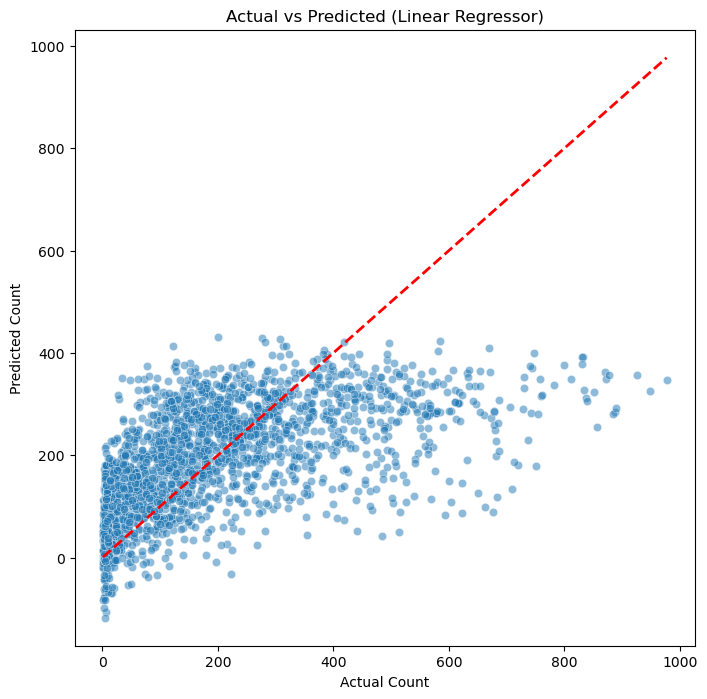

In [144]:
#선형회귀모델 예측결과 시각화
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5) # 실제값과 예측값 시각화
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45도 기준선

plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted (Linear Regressor)')
plt.show()

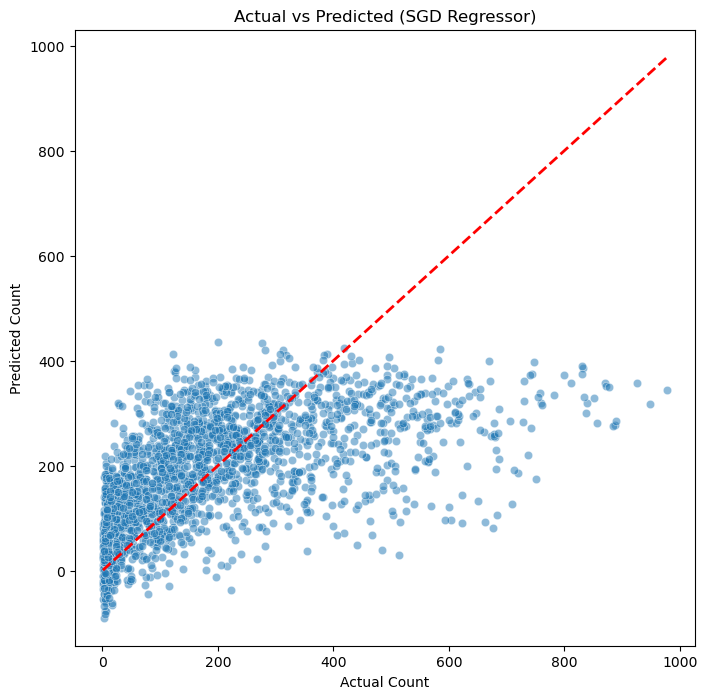

In [145]:
# SGD 경사하강법 결과 시각화
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_sgd, alpha=0.5) # 실제값과 예측값 시각화
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45도 기준선

plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted (SGD Regressor)')
plt.show()

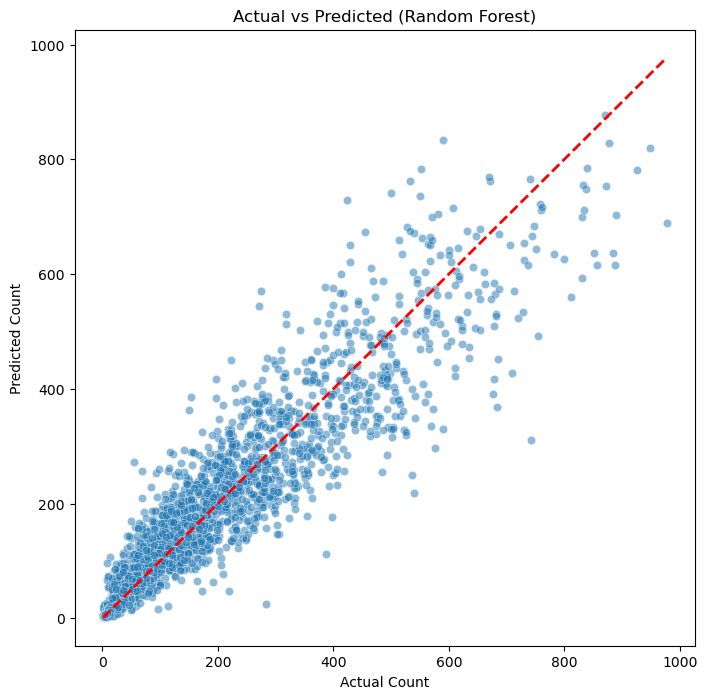

In [143]:
#랜덤 포레스트 예측 결과 시각화
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5) # 실제값과 예측값 시각화
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45도 기준선

plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted (Random Forest)')
plt.show()

# 3개 모델의 예측 결과 비교 시각화

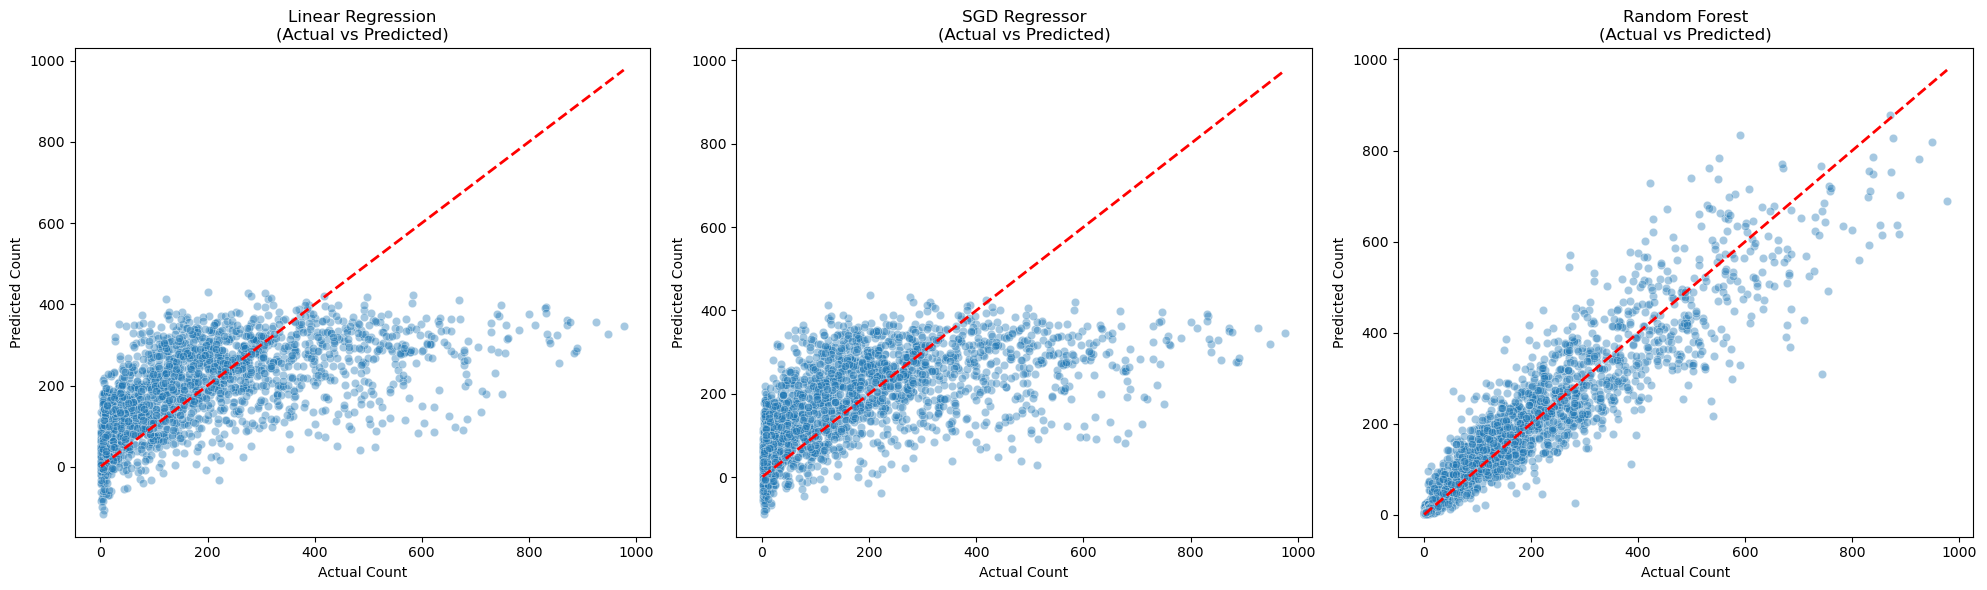

In [146]:
# 3개 그래프를 한번에 띄우기
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models = ['Linear Regression', 'SGD Regressor', 'Random Forest']
preds = [y_pred, y_pred_sgd, y_pred_rf]

for i, (name, pred) in enumerate(zip(models, preds)):
    sns.scatterplot(x=y_test, y=pred, ax=axes[i], alpha=0.4)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_title(f'{name}\n(Actual vs Predicted)')
    axes[i].set_xlabel('Actual Count')
    axes[i].set_ylabel('Predicted Count')

plt.tight_layout()
plt.show()

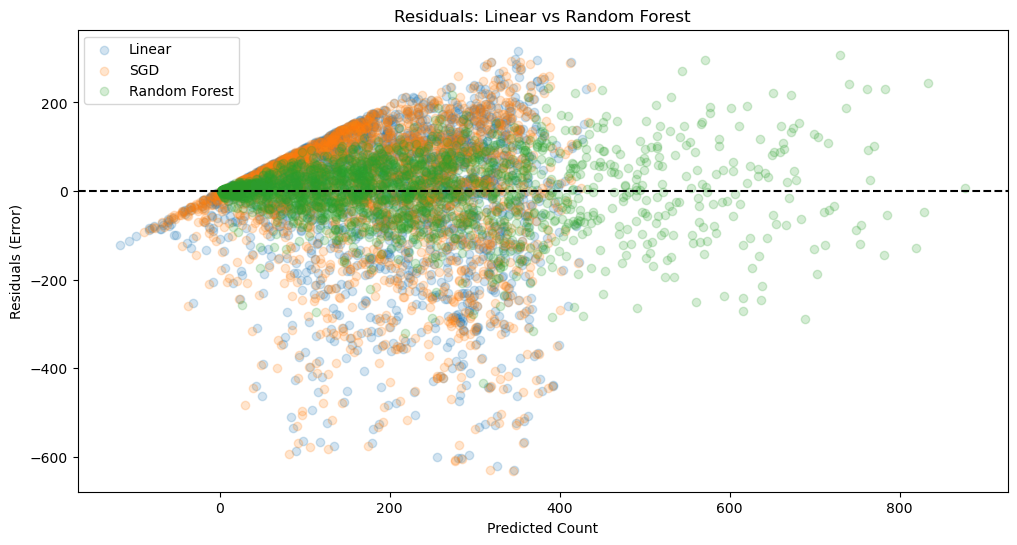

In [151]:
# 얼마나 맞췄는지가 아닌 얼마나 틀렸는지 비교하는 잔차도 그래프
plt.figure(figsize=(12, 6))
plt.scatter(y_pred, y_pred - y_test, alpha=0.2, label='Linear')
plt.scatter(y_pred_sgd, y_pred_sgd - y_test, alpha=0.2, label='SGD')
plt.scatter(y_pred_rf, y_pred_rf - y_test, alpha=0.2, label='Random Forest')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals: Linear vs Random Forest')
plt.xlabel('Predicted Count')
plt.ylabel('Residuals (Error)')
plt.legend()
plt.show()

In [ ]:
# 예측 결과가 Zero Line에  가까울수록 잘맞춘거고 퍼질수록 오답이 큰것입니다. 
# 확실히 RMSE 수치대로 Random Forest모델이 저 선에 가깝게 모여있는것을 알수 있습니다.

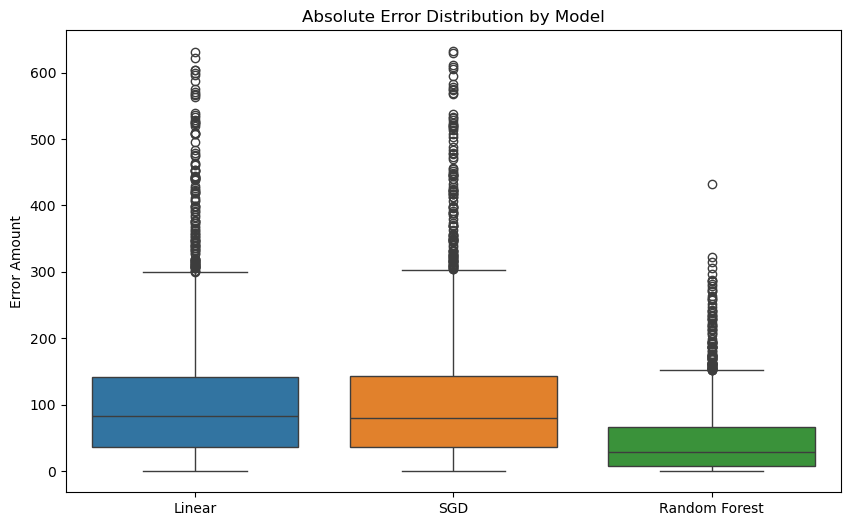

In [152]:
errors = pd.DataFrame({
    'Linear': np.abs(y_test - y_pred),
    'SGD': np.abs(y_test - y_pred_sgd),
    'Random Forest': np.abs(y_test - y_pred_rf)
})

plt.figure(figsize=(10, 6))
sns.boxplot(data=errors)
plt.title('Absolute Error Distribution by Model')
plt.ylabel('Error Amount')
plt.show()

In [ ]:
# 오차 박스그래프는 박스가 아래에 위치할수록 평균적으로 잘 맞추는것입니다.
# 박스 위 아래에 멀리보이는 점들은 이상치가 얼마나 많고 얼마나 넓게 분포되어있는지
# 가늠하는데 도움이 됩니다. 수염(Whiskers)라는 용어를 쓴다고 하네요.

# 랜덤 포레스트 모델조차 수염이 160~300 사이에 많이 분포되어있고, 450정도에도 하나가 보이는데
# 이는 이상치가 꽤많이 존재해서 아주 정확하게 맞출수있는 모델까지는 되지못했다는걸 증명합니다.
# 실제 상용서비스로 쓰려면 높은 정확도, 높은 재현율이 중요하겠죠.

# 온도 습도에 대한 예측결과 시각화

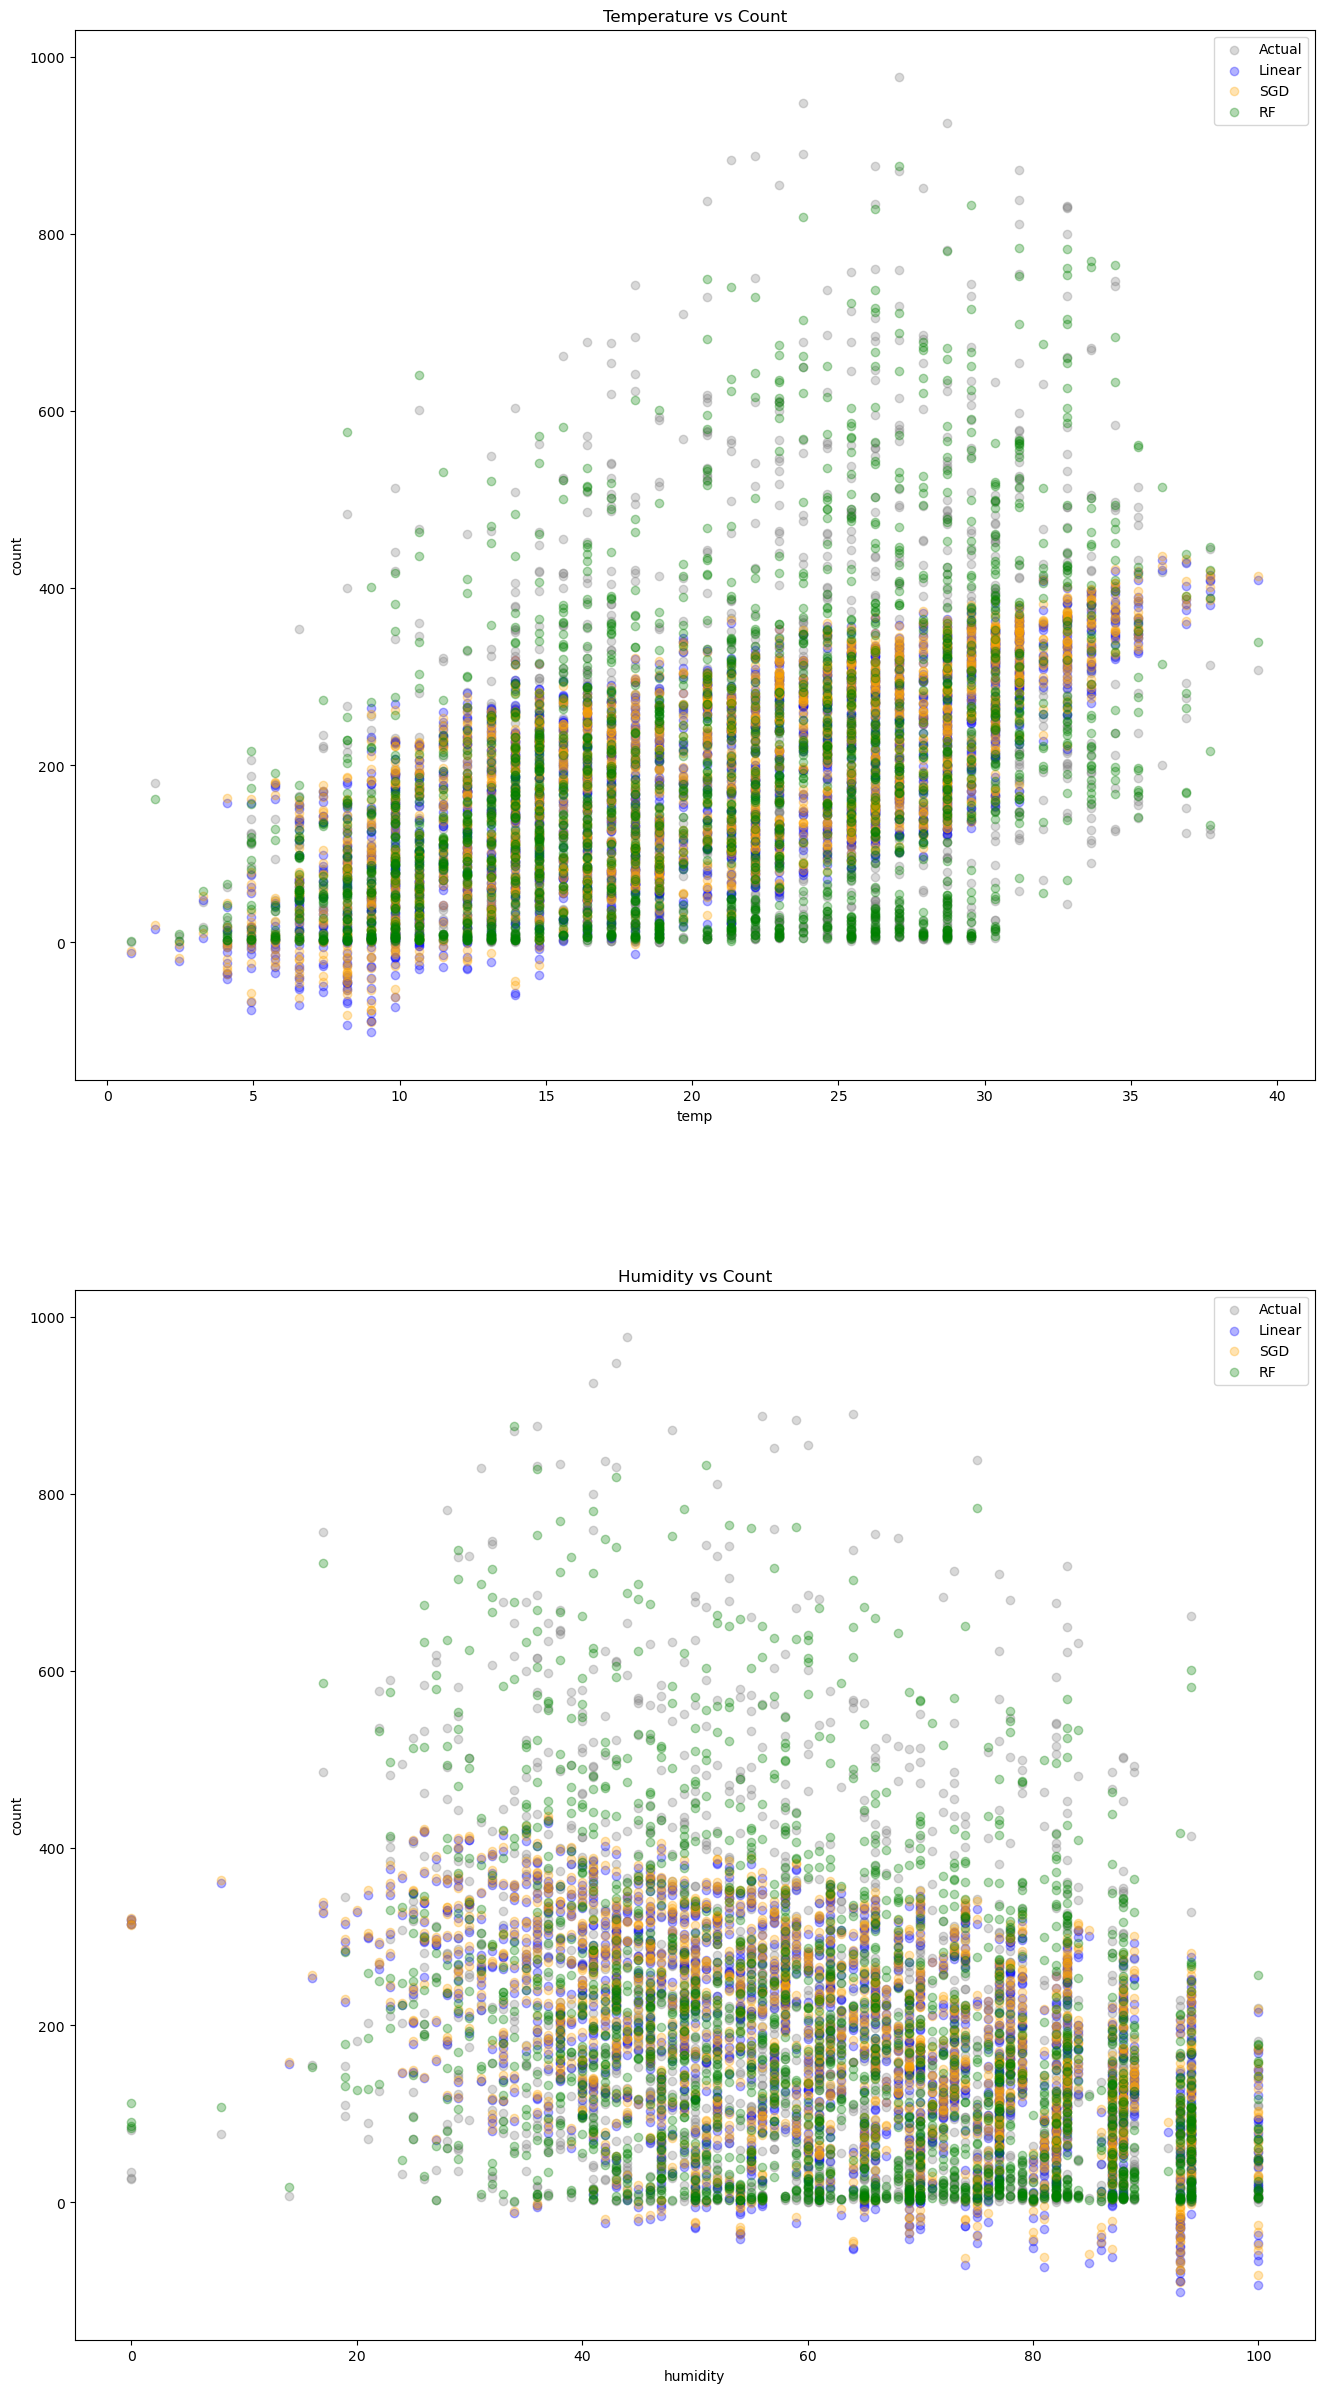

In [58]:
fig, axs = plt.subplots(2, 1, figsize=(16, 30))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='grey', label='Actual', alpha=0.3)
axs[0].scatter(X_test['temp'], y_pred, color='blue', label='Linear', alpha=0.3)
axs[0].scatter(X_test['temp'], y_pred_sgd, color='orange', label='SGD', alpha=0.3)
axs[0].scatter(X_test['temp'], y_pred_rf, color='green', label='RF', alpha=0.3)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='grey', label='Actual', alpha=0.3)
axs[1].scatter(X_test['humidity'], y_pred, color='blue', label='Linear', alpha=0.3)
axs[1].scatter(X_test['humidity'], y_pred_sgd, color='orange', label='SGD', alpha=0.3)
axs[1].scatter(X_test['humidity'], y_pred_rf, color='green', label='RF', alpha=0.3)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()



In [ ]:
# 두 가지모델을 한곳에 띄워서 알아보기 힘든데요.
# 눈에 띄는점은 실제 결과가 집중적으로 분포된부분은 선형모델들이 잘예측을 하지만 
# 작게 분포 (그래프에서 상단부분) 에서는 실제결과 (회색) 과 RF모델의 예측결과(녹색) 말고는 찾아보기 힘듭니다.
# 선형모델인 파란색과 SGD모델인 주황색은 거의 안보이죠.